<a href="https://colab.research.google.com/github/ty202503337/MIT-209-PROJECT/blob/main/logistic_regression_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd

csv_file_path = '/content/drive/MyDrive/Datasets/marketing_campaign.csv'

try:
    df = pd.read_csv(csv_file_path, sep='\t')
    print(f"Successfully loaded {csv_file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded /content/drive/MyDrive/Datasets/marketing_campaign.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Data Preparation and Feature Engineering

### 1. Data Cleaning
This section focuses on cleaning the raw dataset by addressing duplicates, handling missing values, fixing inconsistencies, and encoding categorical features.

#### A. Checking for Duplicates
We will identify and remove any duplicate rows in the dataset to ensure data integrity.

In [20]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

print(f"New shape after duplicate check: {df.shape}")
display(df.head())

Number of duplicate rows found: 0
New shape after duplicate check: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


#### B. Handling Missing Values and Inconsistencies
Will address missing `Income` values and handle age inconsistencies by removing unrealistic age entries.

In [21]:
print("Missing values per column:")
print(df.isnull().sum())

if df['Income'].isnull().any():
    df['Income'] = df['Income'].fillna(df['Income'].median())
    print("\nMissing Income values filled with median.")

current_year = 2015
df['Age'] = current_year - df['Year_Birth']

df = df[(df['Age'] >= 18) & (df['Age'] <= 90)]

income_limit = 200000
outlier_income = df[df['Income'] > income_limit]
if not outlier_income.empty:
    print(f"Removing {len(outlier_income)} records with Income > {income_limit}.")
    df = df[df['Income'] <= income_limit]

print(f"\nFinal shape after cleaning: {df.shape}")
display(df.describe())

Missing values per column:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Missing Income values filled with median.
Removing 1 records with Income > 200000.

Final shape after cleaning: (2236, 30)


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.00000,2236.000000,2236.000000,2236.000000,...,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.0,2236.0,2236.000000,2236.000000
mean,5589.008497,1968.898032,51952.614043,0.444097,0.506708,49.116279,304.12746,26.275939,166.983453,37.536225,...,0.072898,0.074687,0.072451,0.064401,0.013417,0.008945,3.0,11.0,0.149374,46.101968
std,3244.826887,11.703281,21411.466851,0.538459,0.544609,28.957284,336.59181,39.724007,225.689645,54.648562,...,0.260027,0.262944,0.259291,0.245520,0.115077,0.094173,0.0,0.0,0.356536,11.703281
min,0.000000,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,19.000000
25%,2828.250000,1959.000000,35502.500000,0.000000,0.000000,24.000000,24.00000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,38.000000
50%,5454.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.00000,8.000000,67.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000
75%,8421.750000,1977.000000,68275.750000,1.000000,1.000000,74.000000,504.25000,33.000000,232.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,56.000000
max,11191.000000,1996.000000,162397.000000,2.000000,2.000000,99.000000,1493.00000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,75.000000


#### C. Categorical Data Cleaning and Encoding
We will simplify `Education` and `Marital_Status` columns by grouping rare or redundant categories and then apply encoding.

In [22]:
import numpy as np

df['Education'] = df['Education'].replace({'Basic': 'Undergraduate', '2n Cycle': 'Postgraduate', 'Graduation': 'Graduate', 'Master': 'Postgraduate', 'PhD': 'Postgraduate'})

# Grouping 'Alone', 'Absurd', and 'YOLO' into 'Single'
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single', 'Together': 'Partner', 'Married': 'Partner'})

print("Unique values in Education:", df['Education'].unique())
print("Unique values in Marital_Status:", df['Marital_Status'].unique())

print(f"\nRemaining nulls: {df.isnull().sum().sum()}")

Unique values in Education: ['Graduate' 'Postgraduate' 'Undergraduate']
Unique values in Marital_Status: ['Single' 'Partner' 'Divorced' 'Widow']

Remaining nulls: 0


Now, we will perform **Label Encoding** for ordinal data (`Education`) and **One-Hot Encoding** for nominal data (`Marital_Status`).

In [23]:
from sklearn.preprocessing import LabelEncoder

education_order = {'Undergraduate': 0, 'Graduate': 1, 'Postgraduate': 2}
df['Education_Encoded'] = df['Education'].map(education_order)

df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital')

print("Encoded columns preview:")
display(df[['Education', 'Education_Encoded'] + [col for col in df.columns if 'Marital_' in col]].head())

Encoded columns preview:


,Education,Education_Encoded,Marital_Divorced,Marital_Partner,Marital_Single,Marital_Widow
0,Graduate,1,False,False,True,False
1,Graduate,1,False,False,True,False
2,Graduate,1,False,True,False,False
3,Graduate,1,False,True,False,False
4,Postgraduate,2,False,True,False,False


#### D. Date/Time Formatting
Converting `Dt_Customer` from a string to a datetime object to facilitate time-series analysis and feature engineering.

In [24]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

print(f"Customer enrollment ranges from {df['Dt_Customer'].min()} to {df['Dt_Customer'].max()}")
display(df[['Dt_Customer']].head())

Customer enrollment ranges from 2012-07-30 00:00:00 to 2014-06-29 00:00:00


,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19


### 2. Feature Engineering
In this section, new features will be created to better capture customer behavior and demographics.

#### A. Creating New Features
We will create `Enrollment_Days`, `Total_Spend`, and `Total_Dependents` from existing columns.

In [25]:
reference_date = df['Dt_Customer'].max()
df['Enrollment_Days'] = (reference_date - df['Dt_Customer']).dt.days

# Total Spend across all product categories
spend_cols = [col for col in df.columns if 'Mnt' in col]
df['Total_Spend'] = df[spend_cols].sum(axis=1)

# Total Dependents (Kids + Teens)
df['Total_Dependents'] = df['Kidhome'] + df['Teenhome']

display(df[['Dt_Customer', 'Enrollment_Days', 'Total_Spend', 'Total_Dependents']].head())

,Dt_Customer,Enrollment_Days,Total_Spend,Total_Dependents
0,2012-09-04,663,1617,0
1,2014-03-08,113,27,2
2,2013-08-21,312,776,0
3,2014-02-10,139,53,1
4,2014-01-19,161,422,1


#### B. Dropping Irrelevant and Constant Features
Removing columns that don't provide predictive power or variance, including PII (Personally Identifiable Information) and other redundant features.

In [26]:
spend_cols = [col for col in df.columns if 'Mnt' in col]
cols_to_drop = ['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Education', 'Dt_Customer'] + spend_cols

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df.shape}")
display(df.head())

Dropped columns: ['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Education', 'Dt_Customer', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
New shape: (2236, 25)


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,...,Response,Age,Education_Encoded,Marital_Divorced,Marital_Partner,Marital_Single,Marital_Widow,Enrollment_Days,Total_Spend,Total_Dependents
0,58138.0,0,0,58,3,8,10,4,7,0,...,1,58,1,False,False,True,False,663,1617,0
1,46344.0,1,1,38,2,1,1,2,5,0,...,0,61,1,False,False,True,False,113,27,2
2,71613.0,0,0,26,1,8,2,10,4,0,...,0,50,1,False,True,False,False,312,776,0
3,26646.0,1,0,26,2,2,0,4,6,0,...,0,31,1,False,True,False,False,139,53,1
4,58293.0,1,0,94,5,5,3,6,5,0,...,0,34,2,False,True,False,False,161,422,1


#### C. Feature Scaling
Normalize and standardize numerical features to bring them onto a similar scale. We will use `StandardScaler` for standardization.

In [27]:
from sklearn.preprocessing import StandardScaler

num_cols_for_scaling = df.select_dtypes(include=np.number).columns.tolist()
if 'Response' in num_cols_for_scaling:
    num_cols_for_scaling.remove('Response')
if 'Education_Encoded' in num_cols_for_scaling:
    num_cols_for_scaling.remove('Education_Encoded')

# Remove Marital Status one-hot encoded columns from scaling as they are already 0/1
marital_cols = [col for col in df.columns if 'Marital_' in col]
for col in marital_cols:
    if col in num_cols_for_scaling:
        num_cols_for_scaling.remove(col)

# Standardizing (Z-score normalization)
scaler_std = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols_for_scaling] = scaler_std.fit_transform(df[num_cols_for_scaling])

print("Data after Standardization (StandardScaler):")
display(df_scaled[num_cols_for_scaling].head())

Data after Standardization (StandardScaler):


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,Enrollment_Days,Total_Spend,Total_Dependents
0,0.288947,-0.824939,-0.930615,0.306856,0.348738,1.407639,2.509801,-0.552429,0.692865,-0.28041,-0.284104,-0.279482,-0.262362,-0.116616,-0.095001,1.016868,1.529793,1.680176,-1.264308
1,-0.262003,1.032627,0.905974,-0.383971,-0.168700,-1.110921,-0.568970,-1.167738,-0.131421,-0.28041,-0.284104,-0.279482,-0.262362,-0.116616,-0.095001,1.273264,-1.191143,-0.962202,1.395139
2,0.918423,-0.824939,-0.930615,-0.798467,-0.686137,1.407639,-0.226884,1.293496,-0.543564,-0.28041,-0.284104,-0.279482,-0.262362,-0.116616,-0.095001,0.333146,-0.206659,0.282541,-1.264308
3,-1.182183,1.032627,-0.930615,-0.798467,-0.168700,-0.751127,-0.911056,-0.552429,0.280722,-0.28041,-0.284104,-0.279482,-0.262362,-0.116616,-0.095001,-1.290693,-1.062517,-0.918994,0.065416
4,0.296187,1.032627,-0.930615,1.550344,1.383614,0.328256,0.115201,0.062879,-0.131421,-0.28041,-0.284104,-0.279482,-0.262362,-0.116616,-0.095001,-1.034298,-0.953679,-0.305762,0.065416


### 3. Preparing Datasets for ML Experiments
Define the features (`X`) and target (`y`), then create Train/Test splits for the standardized version. And address class imbalance using SMOTE.

In [28]:
from sklearn.model_selection import train_test_split

y = df_scaled['Response']
X_scaled = df_scaled.drop(columns=['Response'])

test_size = 0.2
random_state = 42

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=random_state)

print(f"Total records: {len(df_scaled)}")
print(f"Training records: {len(X_train_scaled)}")
print(f"Testing records: {len(X_test_scaled)}")
print("\nStandardized datasets are ready for experimentation.")

Total records: 2236
Training records: 1788
Testing records: 448

Standardized datasets are ready for experimentation.


### 4. Handling Class Imbalance (SMOTE)
Checking the distribution of the chosen target variable `Response` to confirm the imbalance, then applying SMOTE to balance the training sets.

Original class distribution: Counter({0: 1527, 1: 261})


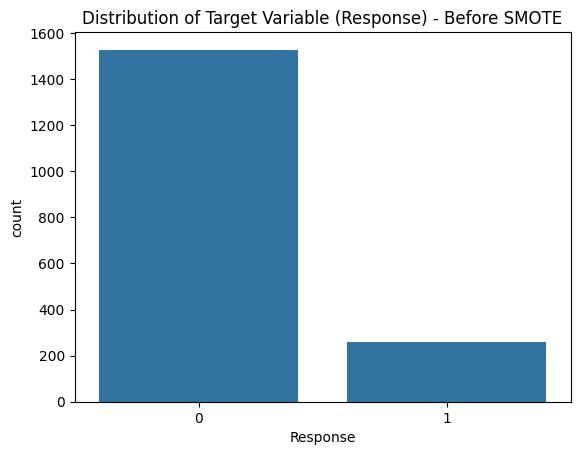

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original class distribution: {Counter(y_train)}")

sns.countplot(x=y_train)
plt.title('Distribution of Target Variable (Response) - Before SMOTE')
plt.show()

Balanced class distribution: Counter({1: 1527, 0: 1527})


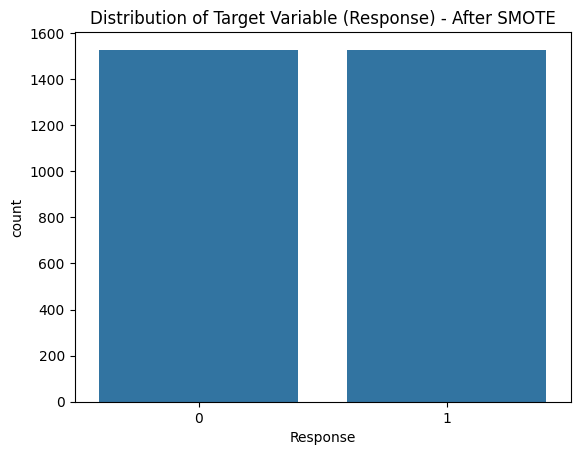

In [30]:
smote = SMOTE(random_state=42)

X_train_scaled_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced class distribution: {Counter(y_train_bal)}")

sns.countplot(x=y_train_bal)
plt.title('Distribution of Target Variable (Response) - After SMOTE')
plt.show()

### 5. Baseline Model: Logistic Regression
Train a Logistic Regression model on the standardized, balanced training data and evaluating its performance on the standardized test set.

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.92      0.87      0.90       375
           1       0.48      0.60      0.54        73

    accuracy                           0.83       448
   macro avg       0.70      0.74      0.72       448
weighted avg       0.85      0.83      0.84       448

ROC-AUC Score: 0.8791


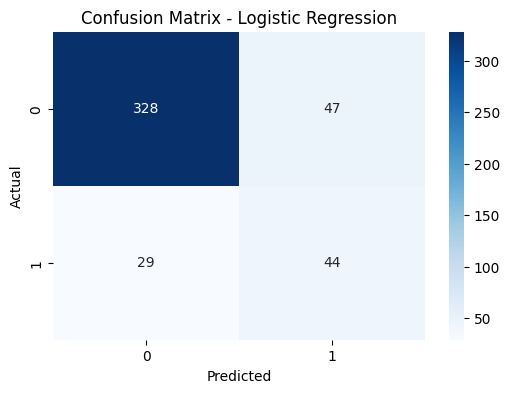

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(random_state=42, max_iter=5000)
log_reg.fit(X_train_scaled_bal, y_train_bal)

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# EXPORT MODEL FOR LOGISTIC REGRESSION MODEL

In [33]:
import pickle
import os

logistic_regression_model_save_path = '/content/drive/MyDrive/Datasets/logistic_regression_marketing_model.pkl'

with open(logistic_regression_model_save_path, 'wb') as f:
    pickle.dump(log_reg, f)

print(f"Logistic Regression model successfully saved to: {logistic_regression_model_save_path}")

with open(logistic_regression_model_save_path, 'rb') as f:
    loaded_logistic_regression_model = pickle.load(f)

print(f"Verification: Loaded Logistic Regression model type is {type(loaded_logistic_regression_model)}")

Logistic Regression model successfully saved to: /content/drive/MyDrive/Datasets/logistic_regression_marketing_model.pkl
Verification: Loaded Logistic Regression model type is <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [34]:
output_csv_path = '/content/drive/MyDrive/Datasets/logistic_regression_marketing_campaign.csv'
df_scaled.to_csv(output_csv_path, index=False)
print(f"Cleaned and scaled data exported to: {output_csv_path}")

Cleaned and scaled data exported to: /content/drive/MyDrive/Datasets/logistic_regression_marketing_campaign.csv


## Evaluation Metrics Summary

| Metric        | Value      |
| :------------ | :--------- |
| Accuracy      | 0.83       |
| Precision (Class 1) | 0.48       |
| Recall (Class 1)    | 0.60       |
| F1-Score (Class 1)  | 0.54       |
| ROC-AUC Score | 0.8791     |